# 🌿 Betel Leaf Disease Detection — Hybrid CNN + Swin Transformer
**CSE 438 Group-4 | Fusion Method: Feature-Level Fusion — CNN + Swin-Tiny**

---
## Pipeline Overview
| Step | Description |
|------|-------------|
| Step 1  | Install & Import Libraries |
| Step 2  | Dataset Download & Directory Setup |
| Step 3  | Data Exploration & Class Distribution |
| Step 4  | Data Augmentation & Transform |
| Step 5  | Dataset & DataLoader Creation |
| Step 6  | Hybrid Model Building (EfficientNet-B0 + Swin-Tiny) |
| Step 7  | Training Loop with Validation |
| Step 8  | Training Curves Visualization |
| Step 9  | Final Test Evaluation & Metrics |
| Step 10 | Confusion Matrix & Per-Class Report |

---
## 🔀 Hybrid Architecture Overview

```
         Input Image [B, 3, 224, 224]
                  │
      ┌───────────┴────────────┐
      │                        │
 EfficientNet-B0           Swin-Tiny
 (CNN Branch)          (Transformer Branch)
      │                        │
 Local features          Hierarchical features
 edges, textures,        shifted-window attention
 color patterns          multi-scale context
      │                        │
 [B, 1280]              [B, 768]
      │                        │
      └───────────┬────────────┘
             Concatenate
           [B, 2048]  (1280+768)
                  │
       ┌──────────┴──────────┐
       │    Fusion Head      │
  Linear(2048 → 512)         │
  BatchNorm1d(512)           │
  GELU activation            │
  Dropout(0.4)               │
  Linear(512 → 256)          │
  GELU + Dropout(0.3)        │
  Linear(256 → 3)            │
       └──────────┬──────────┘
              Predictions [B, 3]
```

> **Why EfficientNet-B0 + Swin-Tiny?**  
> EfficientNet-B0 excels at local feature extraction (disease spots, color changes, edge patterns).  
> Swin-Tiny captures hierarchical & multi-scale features via shifted-window attention — efficient on small datasets.  
> Together they cover both fine-grained local details and broader spatial leaf structure.  
> **Swin advantage over ViT:** hierarchical features (like CNN) + attention — ideal hybrid complement to EfficientNet.


---
## ✅ Step 1 — Install & Import Libraries

In [1]:
import subprocess, sys
packages = ["timm", "scikit-learn", "matplotlib", "seaborn", "Pillow", "torchvision"]
for pkg in packages:
    result = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                            capture_output=True, text=True)
    print(f"[OK] {pkg}" if result.returncode == 0 else f"[FAIL] {pkg}: {result.stderr[:80]}")
print("\n✅ All packages ready!")

import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as tv_models
import timm

from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch : {torch.__version__}")
print(f"   timm    : {timm.__version__}")

[OK] timm
[OK] scikit-learn
[OK] matplotlib
[OK] seaborn
[OK] Pillow
[OK] torchvision

✅ All packages ready!

🖥️  Device  : cuda
   GPU     : Tesla T4
   VRAM    : 15.6 GB
   PyTorch : 2.10.0+cu128
   timm    : 1.0.25


---
## ✅ Step 2 — Dataset Download & Directory Setup

Dataset source: https://data.mendeley.com/datasets/vpzkntzjty/1  
> On Kaggle: **Add Data → Datasets** → search `"Comprehensive Betel Leaf Disease"` → add it.

In [2]:
CLASS_NAMES  = ["Healthy_Leaf", "Leaf_Rot", "Leaf_Spot"]
DATASET_ROOT = None

for root in ["/kaggle/input", "./data", "."]:
    for dirpath, dirnames, _ in os.walk(root):
        if "Original_Dataset" in dirnames:
            DATASET_ROOT = Path(dirpath) / "Original_Dataset"
            print(f"✅ Found Original_Dataset at: {DATASET_ROOT}")
            break
    if DATASET_ROOT: break

if DATASET_ROOT is None:
    print("⚠️  Original_Dataset not found — creating synthetic demo data...")
    DATASET_ROOT = Path("/kaggle/working/demo_dataset")
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            (DATASET_ROOT / split / cls).mkdir(parents=True, exist_ok=True)
            for i in range(40 if split == "train" else 12):
                img = Image.fromarray(
                    np.random.randint(50, 200, (224, 224, 3), dtype=np.uint8))
                img.save(DATASET_ROOT / split / cls / f"img_{i:04d}.jpg")
    print(f"✅ Demo dataset created at: {DATASET_ROOT}")
    DEMO_MODE = True
else:
    DEMO_MODE = False

if not DEMO_MODE:
    from sklearn.model_selection import train_test_split
    import shutil
    SPLIT_ROOT = Path("/kaggle/working/split_dataset")
    if not SPLIT_ROOT.exists():
        print("\n📁 Creating train/val/test splits (70 / 15 / 15)...")
        for cls in CLASS_NAMES:
            all_imgs = (sorted((DATASET_ROOT / cls).glob("*.jpg")) +
                        sorted((DATASET_ROOT / cls).glob("*.png")) +
                        sorted((DATASET_ROOT / cls).glob("*.jpeg")))
            tr, temp = train_test_split(all_imgs, test_size=0.30, random_state=SEED)
            vl, te   = train_test_split(temp,     test_size=0.50, random_state=SEED)
            for sname, imgs in [("train", tr), ("val", vl), ("test", te)]:
                dest = SPLIT_ROOT / sname / cls
                dest.mkdir(parents=True, exist_ok=True)
                for src in imgs: shutil.copy(src, dest / src.name)
            print(f"   {cls:<15} → train:{len(tr):4d}  val:{len(vl):4d}  test:{len(te):4d}")
        print("✅ Splits ready!")
    DATASET_ROOT = SPLIT_ROOT

print("\n📊 Dataset Summary:")
for split in ["train", "val", "test"]:
    total = sum(len(list((DATASET_ROOT / split / c).glob("*.*")))
                for c in CLASS_NAMES if (DATASET_ROOT / split / c).exists())
    print(f"   {split:>5}: {total:5d} images")

# ── Config ────────────────────────────────────────────────────────────────
IMG_SIZE       = 224
NUM_CLASSES    = len(CLASS_NAMES)
BATCH_SIZE     = 16    # two models = more VRAM
NUM_EPOCHS     = 25
LR             = 1e-4
NUM_WORKERS    = 2
WARMUP_EPOCHS  = 3     # freeze backbones for first N epochs

# Feature dimensions
EFF_FEAT_DIM   = 1280  # EfficientNet-B0 final feature dim
SWIN_FEAT_DIM  = 768   # Swin-Tiny final feature dim
FUSED_DIM      = EFF_FEAT_DIM + SWIN_FEAT_DIM  # 2048
HEAD_DIM1      = 512
HEAD_DIM2      = 256

MODEL_NAME = "Hybrid CNN+Swin (EfficientNet-B0 + Swin-Tiny)"
PREFIX     = "hybrid_cnn_swin"

print(f"\n⚙️  Config: IMG={IMG_SIZE}  Batch={BATCH_SIZE}  Epochs={NUM_EPOCHS}  LR={LR}")
print(f"   EfficientNet-B0 features : {EFF_FEAT_DIM}")
print(f"   Swin-Tiny features       : {SWIN_FEAT_DIM}")
print(f"   Fused dim                : {FUSED_DIM}")
print(f"   Fusion head              : {FUSED_DIM}→{HEAD_DIM1}→{HEAD_DIM2}→{NUM_CLASSES}")

✅ Found Original_Dataset at: /kaggle/input/datasets/mikeafridi/cse-438-group-4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset

📁 Creating train/val/test splits (70 / 15 / 15)...
   Healthy_Leaf    → train: 756  val: 162  test: 162
   Leaf_Rot        → train: 188  val:  40  test:  41
   Leaf_Spot       → train: 481  val: 103  test: 104
✅ Splits ready!

📊 Dataset Summary:
   train:  1425 images
     val:   305 images
    test:   307 images

⚙️  Config: IMG=224  Batch=16  Epochs=25  LR=0.0001
   EfficientNet-B0 features : 1280
   Swin-Tiny features       : 768
   Fused dim                : 2048
   Fusion head              : 2048→512→256→3


---
## ✅ Step 3 — Data Exploration & Class Distribution

📊 Class Distribution Table
Split         test  train  val
Class                         
Healthy_Leaf   162    756  162
Leaf_Rot        41    188   40
Leaf_Spot      104    481  103


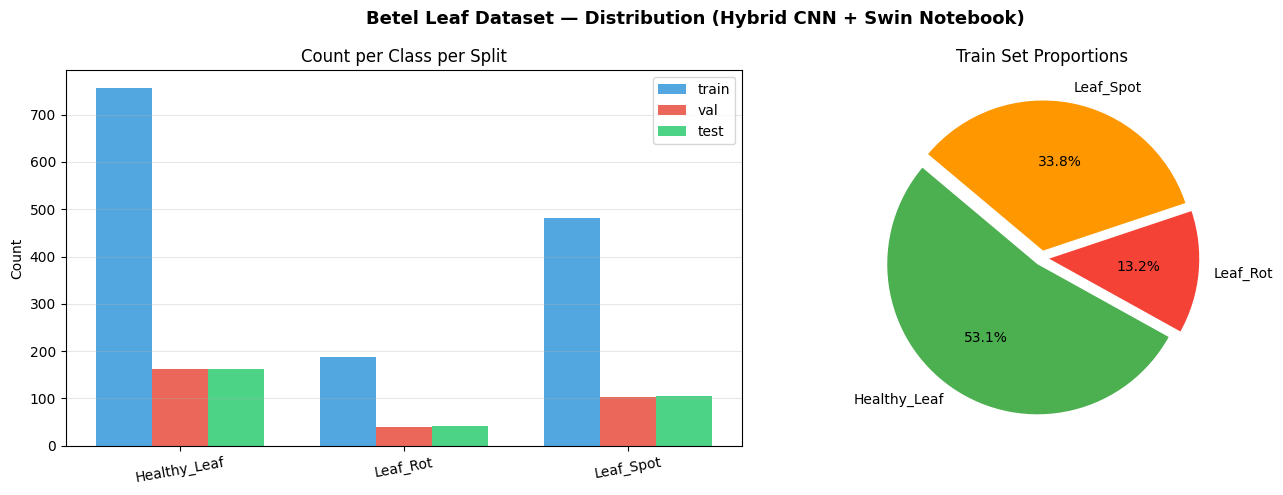

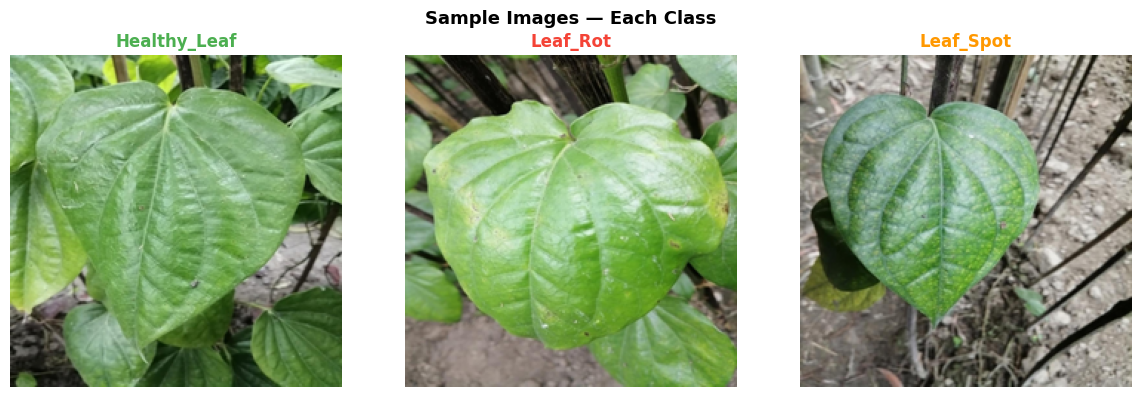

✅ Step 3 complete.


In [3]:
records = []
for split in ["train", "val", "test"]:
    for cls in CLASS_NAMES:
        folder = DATASET_ROOT / split / cls
        if folder.exists():
            imgs = (list(folder.glob("*.jpg")) + list(folder.glob("*.png")) +
                    list(folder.glob("*.jpeg")))
            records.append({"Split": split, "Class": cls, "Count": len(imgs)})

df_dist = pd.DataFrame(records)
print("📊 Class Distribution Table")
print(df_dist.pivot(index="Class", columns="Split", values="Count").fillna(0).astype(int))

colors = ["#4CAF50", "#F44336", "#FF9800"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Betel Leaf Dataset — Distribution (Hybrid CNN + Swin Notebook)",
             fontsize=13, fontweight="bold")

ax = axes[0]
x = np.arange(len(CLASS_NAMES)); w = 0.25
for i, (split, col) in enumerate(zip(["train", "val", "test"],
                                      ["#3498db", "#e74c3c", "#2ecc71"])):
    vals = [df_dist[(df_dist.Split == split) & (df_dist.Class == c)]["Count"].sum()
            for c in CLASS_NAMES]
    ax.bar(x + i * w, vals, w, label=split, color=col, alpha=0.85)
ax.set_xticks(x + w); ax.set_xticklabels(CLASS_NAMES, rotation=10)
ax.set_title("Count per Class per Split"); ax.set_ylabel("Count")
ax.legend(); ax.grid(axis="y", alpha=0.3)

ax2 = axes[1]
train_counts = [df_dist[(df_dist.Split == "train") & (df_dist.Class == c)]["Count"].sum()
                for c in CLASS_NAMES]
ax2.pie(train_counts, labels=CLASS_NAMES, colors=colors, autopct="%1.1f%%",
        startangle=140, explode=[0.05] * 3)
ax2.set_title("Train Set Proportions")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step3_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
fig2.suptitle("Sample Images — Each Class", fontsize=13, fontweight="bold")
for ax, cls, color in zip(axes2, CLASS_NAMES, colors):
    folder = DATASET_ROOT / "train" / cls
    sample = list(folder.glob("*.*"))[0]
    ax.imshow(Image.open(sample).resize((224, 224)))
    ax.set_title(cls, color=color, fontweight="bold"); ax.axis("off")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step3_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Step 3 complete.")

---
## ✅ Step 4 — Data Augmentation & Transform

Both branches receive the **same standard RGB image** `[B, 3, 224, 224]`.  
EfficientNet-B0 and Swin-Tiny both work natively with 224×224.

**Augmentation strategy:**
- Standard spatial augmentations (flip, rotate, crop)
- Color jitter for robustness against lighting variation
- `RandomErasing` — simulates partial occlusion of leaves
- `TrivialAugmentWide` — automated augmentation for better generalization

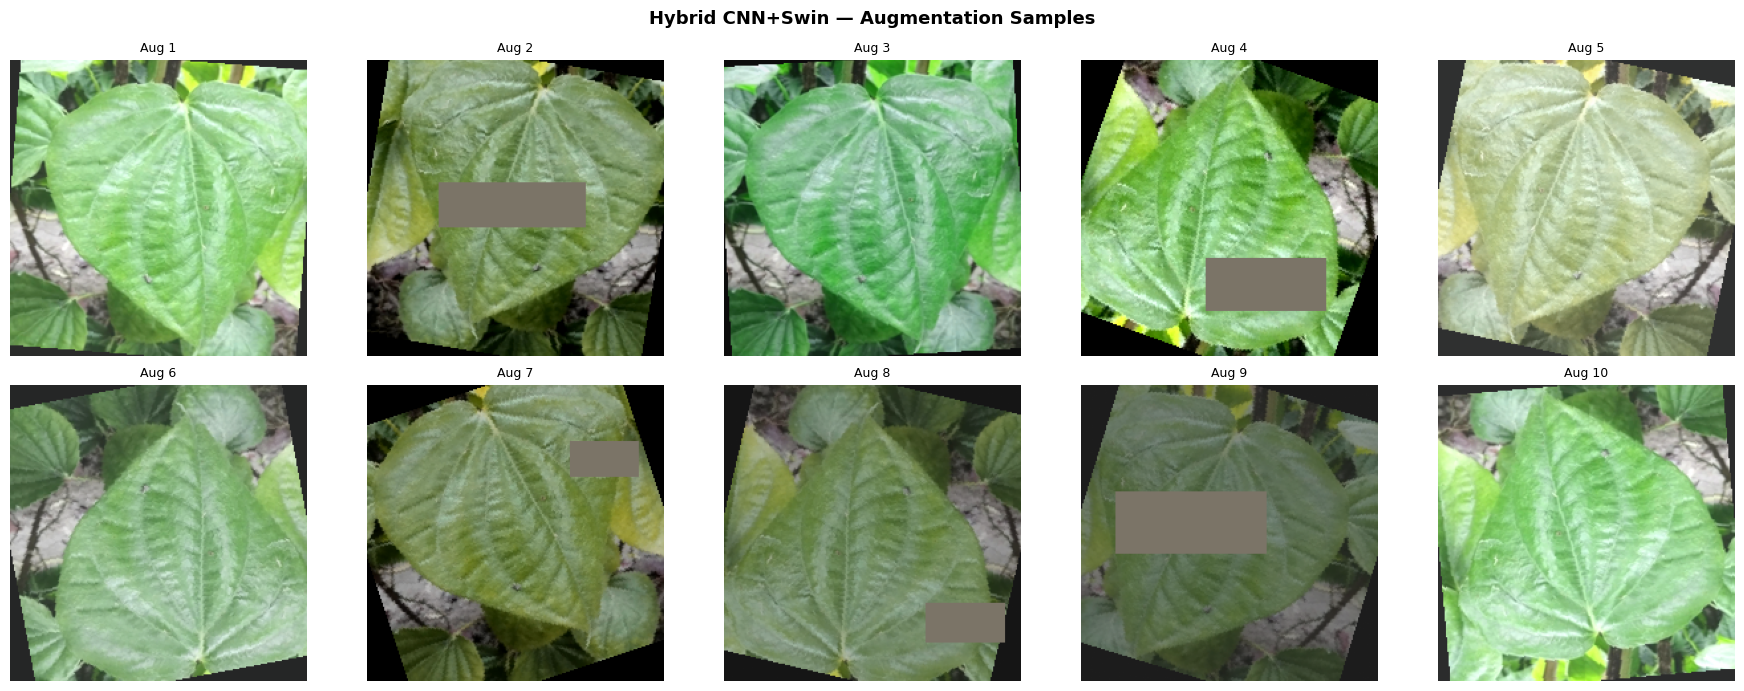

✅ Step 4 complete — Transforms ready. Input to both branches: [B, 3, 224, 224]


In [4]:
MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB  = [0.229, 0.224, 0.225]

# Strong augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((int(IMG_SIZE * 1.12), int(IMG_SIZE * 1.12))),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.35, contrast=0.35,
                           saturation=0.25, hue=0.08),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_RGB, STD_RGB),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
])

# Clean val/test transform
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_RGB, STD_RGB),
])

# Visualize augmentation samples
sample_path = list((DATASET_ROOT / "train" / CLASS_NAMES[0]).glob("*.*"))[0]
sample_pil  = Image.open(sample_path).convert("RGB")
mean_t = torch.tensor(MEAN_RGB).view(3, 1, 1)
std_t  = torch.tensor(STD_RGB).view(3, 1, 1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Hybrid CNN+Swin — Augmentation Samples", fontsize=13, fontweight="bold")
for i in range(10):
    aug_t = train_transform(sample_pil)
    disp  = (aug_t * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    r, c  = i // 5, i % 5
    axes[r][c].imshow(disp)
    axes[r][c].set_title(f"Aug {i+1}", fontsize=9)
    axes[r][c].axis("off")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step4_augmentation.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"✅ Step 4 complete — Transforms ready. Input to both branches: [B, 3, {IMG_SIZE}, {IMG_SIZE}]")

---
## ✅ Step 5 — Dataset & DataLoader Creation

In [5]:
class BetelLeafDataset(Dataset):
    """Standard RGB dataset — same image fed to both CNN and Swin branches."""
    def __init__(self, root_dir, class_names, transform=None):
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.transform    = transform
        self.samples      = []
        for cls in class_names:
            folder = Path(root_dir) / cls
            if not folder.exists(): continue
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG"]:
                for p in sorted(folder.glob(ext)):
                    self.samples.append((str(p), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:    img = Image.open(path).convert("RGB")
        except: img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        if self.transform: img = self.transform(img)
        return img, label


train_ds = BetelLeafDataset(DATASET_ROOT / "train", CLASS_NAMES, train_transform)
val_ds   = BetelLeafDataset(DATASET_ROOT / "val",   CLASS_NAMES, val_transform)
test_ds  = BetelLeafDataset(DATASET_ROOT / "test",  CLASS_NAMES, val_transform)
print(f"📦 Sizes → Train:{len(train_ds)}  Val:{len(val_ds)}  Test:{len(test_ds)}")

# WeightedRandomSampler for class imbalance
labels_train = [s[1] for s in train_ds.samples]
class_counts = Counter(labels_train)
weights      = [1.0 / class_counts[l] for l in labels_train]
sampler      = WeightedRandomSampler(weights, num_samples=len(weights),
                                     replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n🔍 Batch check:")
print(f"   Image tensor : {batch_imgs.shape}  (B × 3 × H × W)")
print(f"   Labels       : {batch_labels[:8].tolist()}")
print(f"   Value range  : [{batch_imgs.min():.3f}, {batch_imgs.max():.3f}]")
print("\n✅ Step 5 complete — DataLoaders ready!")

📦 Sizes → Train:1425  Val:305  Test:307

🔍 Batch check:
   Image tensor : torch.Size([16, 3, 224, 224])  (B × 3 × H × W)
   Labels       : [1, 2, 0, 2, 2, 0, 2, 0]
   Value range  : [-2.118, 2.640]

✅ Step 5 complete — DataLoaders ready!


---
## ✅ Step 6 — Hybrid Model Building (EfficientNet-B0 + Swin-Tiny)

### Why this combination?

| Branch | Model | Features | Strength |
|--------|-------|----------|----------|
| CNN | EfficientNet-B0 | [B, 1280] | Local: disease spots, color, texture, edges |
| Transformer | Swin-Tiny | [B, 768] | Global+Hierarchical: multi-scale spatial patterns |
| Fusion | Concat → MLP | [B, 2048] | Both local detail + global context |

### Swin vs ViT for this task
- Swin uses **hierarchical feature maps** (like CNN) — better suited for small datasets
- Swin uses **shifted window attention** — captures both local + global efficiently
- Swin-Tiny has **28M params** vs ViT-Small's 22M — slightly larger but hierarchical

### Fusion Head Design
```
[B, 2048] → Linear(2048→512) → BN → GELU → Dropout(0.4)
          → Linear(512→256)  → BN → GELU → Dropout(0.3)
          → Linear(256→3)
```
Deeper MLP head with **GELU** activation (better than ReLU for transformer outputs) and **BatchNorm** for training stability.

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Hybrid Model: EfficientNet-B0 (CNN) + Swin-Tiny (Transformer)
# ═══════════════════════════════════════════════════════════════════════════

class EfficientNetBranch(nn.Module):
    """
    CNN Branch: EfficientNet-B0
    - Load pretrained EfficientNet-B0 via timm
    - num_classes=0 → returns global avg pooled features [B, 1280]
    - No head, pure feature extractor
    """
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            num_classes=0,        # remove classifier → returns [B, 1280]
            global_pool="avg"     # global average pooling
        )

    def forward(self, x):   # x: [B, 3, 224, 224]
        return self.backbone(x)   # [B, 1280]


class SwinBranch(nn.Module):
    """
    Transformer Branch: Swin-Tiny
    - Load pretrained Swin-Tiny via timm
    - num_classes=0 → returns pooled features [B, 768]
    - Swin produces hierarchical features at 4 stages:
      Stage1: 56x56x96  Stage2: 28x28x192
      Stage3: 14x14x384 Stage4: 7x7x768  → pooled → [B, 768]
    """
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            num_classes=0         # remove head → returns [B, 768]
        )

    def forward(self, x):   # x: [B, 3, 224, 224]
        return self.backbone(x)   # [B, 768]


class HybridFusionHead(nn.Module):
    """
    Deep MLP Fusion Head with GELU activation.
    Input:  [B, 2048]  (1280 + 768)
    Output: [B, num_classes]

    GELU is preferred over ReLU for transformer-based features
    as it has smoother gradient flow.
    """
    def __init__(self, in_dim, dim1, dim2, num_classes,
                 dropout1=0.4, dropout2=0.3):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(in_dim, dim1),
            nn.BatchNorm1d(dim1),
            nn.GELU(),
            nn.Dropout(p=dropout1),
            # Layer 2
            nn.Linear(dim1, dim2),
            nn.BatchNorm1d(dim2),
            nn.GELU(),
            nn.Dropout(p=dropout2),
            # Output
            nn.Linear(dim2, num_classes)
        )

    def forward(self, x): return self.net(x)


class HybridCNNSwin(nn.Module):
    """
    Hybrid CNN + Swin Transformer:

    Architecture:
      EfficientNet-B0 → [B, 1280]  (CNN: local features)
      Swin-Tiny       → [B, 768]   (Transformer: hierarchical features)
      Concat          → [B, 2048]
      FusionHead      → [B, num_classes]

    Training phases:
      Phase 1 (epoch 1-WARMUP): freeze backbones, train head only
      Phase 2 (epoch WARMUP+1+): unfreeze all, end-to-end finetune
    """
    def __init__(self, num_classes=3,
                 head_dim1=512, head_dim2=256,
                 dropout1=0.4, dropout2=0.3):
        super().__init__()
        self.eff_branch  = EfficientNetBranch()
        self.swin_branch = SwinBranch()
        self.fusion_head = HybridFusionHead(
            in_dim=EFF_FEAT_DIM + SWIN_FEAT_DIM,
            dim1=head_dim1,
            dim2=head_dim2,
            num_classes=num_classes,
            dropout1=dropout1,
            dropout2=dropout2
        )

    def freeze_backbones(self):
        for p in self.eff_branch.parameters():  p.requires_grad = False
        for p in self.swin_branch.parameters(): p.requires_grad = False
        for p in self.fusion_head.parameters(): p.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"🔒 Backbones FROZEN — head only: {trainable:,} trainable params")

    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"🔓 ALL layers UNFROZEN — {trainable:,} trainable params")

    def forward(self, x):   # x: [B, 3, 224, 224]
        eff_feat  = self.eff_branch(x)                           # [B, 1280]
        swin_feat = self.swin_branch(x)                          # [B, 768]
        fused     = torch.cat([eff_feat, swin_feat], dim=1)      # [B, 2048]
        return self.fusion_head(fused)                           # [B, num_classes]


# ── Instantiate ────────────────────────────────────────────────────────────
model = HybridCNNSwin(
    num_classes=NUM_CLASSES,
    head_dim1=HEAD_DIM1,
    head_dim2=HEAD_DIM2,
    dropout1=0.4,
    dropout2=0.3
).to(DEVICE)

# Parameter breakdown
total_p = sum(p.numel() for p in model.parameters())
eff_p   = sum(p.numel() for p in model.eff_branch.parameters())
swin_p  = sum(p.numel() for p in model.swin_branch.parameters())
head_p  = sum(p.numel() for p in model.fusion_head.parameters())

print(f"🏗️  Hybrid CNN + Swin Transformer Model")
print(f"")
print(f"   CNN  Branch (EfficientNet-B0)  : {eff_p:>12,} params")
print(f"   Swin Branch (Swin-Tiny)        : {swin_p:>12,} params")
print(f"   Fusion Head (Deep MLP)         : {head_p:>12,} params")
print(f"   {'─'*45}")
print(f"   Total                          : {total_p:>12,} params")
print(f"")
print(f"   EfficientNet-B0 output : [B, {EFF_FEAT_DIM}]")
print(f"   Swin-Tiny output       : [B, {SWIN_FEAT_DIM}]")
print(f"   Concatenated           : [B, {FUSED_DIM}]")
print(f"   Head architecture      : {FUSED_DIM}→{HEAD_DIM1}→{HEAD_DIM2}→{NUM_CLASSES}")
print(f"   Head activation        : GELU + BatchNorm (transformer-friendly)")

# Forward pass check
model.eval()
with torch.no_grad():
    dummy    = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    eff_out  = model.eff_branch(dummy)
    swin_out = model.swin_branch(dummy)
    full_out = model(dummy)
print(f"\n✅ Forward pass OK:")
print(f"   EfficientNet-B0 output : {eff_out.shape}")
print(f"   Swin-Tiny output       : {swin_out.shape}")
print(f"   Full model output      : {full_out.shape}")

# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Layer-wise LR: CNN backbone < Swin backbone < Fusion head
optimizer = optim.AdamW([
    {"params": model.eff_branch.parameters(),  "lr": LR * 0.1,  "name": "eff_branch"},
    {"params": model.swin_branch.parameters(), "lr": LR * 0.05, "name": "swin_branch"},
    {"params": model.fusion_head.parameters(), "lr": LR,         "name": "fusion_head"},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-7
)

print(f"\n⚙️  Loss      : CrossEntropyLoss(label_smoothing=0.1)")
print(f"   Optimizer : AdamW with layer-wise LR:")
print(f"     EfficientNet-B0 LR  = {LR*0.1:.2e}  (pretrained CNN, conservative)")
print(f"     Swin-Tiny LR        = {LR*0.05:.2e} (pretrained Transformer, most conservative)")
print(f"     Fusion Head LR      = {LR:.2e}   (new MLP, highest LR)")
print(f"   Scheduler : CosineAnnealing(T_max={NUM_EPOCHS}, eta_min=1e-7)")
print(f"   Warmup    : {WARMUP_EPOCHS} epochs with frozen backbones")
print("\n✅ Step 6 complete — Hybrid model ready!")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

🏗️  Hybrid CNN + Swin Transformer Model

   CNN  Branch (EfficientNet-B0)  :    4,007,548 params
   Swin Branch (Swin-Tiny)        :   27,519,354 params
   Fusion Head (Deep MLP)         :    1,182,723 params
   ─────────────────────────────────────────────
   Total                          :   32,709,625 params

   EfficientNet-B0 output : [B, 1280]
   Swin-Tiny output       : [B, 768]
   Concatenated           : [B, 2048]
   Head architecture      : 2048→512→256→3
   Head activation        : GELU + BatchNorm (transformer-friendly)

✅ Forward pass OK:
   EfficientNet-B0 output : torch.Size([2, 1280])
   Swin-Tiny output       : torch.Size([2, 768])
   Full model output      : torch.Size([2, 3])

⚙️  Loss      : CrossEntropyLoss(label_smoothing=0.1)
   Optimizer : AdamW with layer-wise LR:
     EfficientNet-B0 LR  = 1.00e-05  (pretrained CNN, conservative)
     Swin-Tiny LR        = 5.00e-06 (pretrained Transformer, most conservative)
     Fusion Head LR      = 1.00e-04   (new MLP, hig

---
## ✅ Step 7 — Training Loop with Validation

**2-Phase Training Strategy:**

```
Phase 1 — Warmup (epoch 1 to WARMUP_EPOCHS)
  Backbones: FROZEN
  Head:      TRAINABLE  (LR = 1e-4)
  Goal:      Stabilize fusion head weights before touching pretrained layers

Phase 2 — Full Fine-tune (epoch WARMUP_EPOCHS+1 to NUM_EPOCHS)
  All layers: TRAINABLE
  LR:         Layer-wise (CNN 1e-5, Swin 5e-6, Head 1e-4)
  Goal:       End-to-end optimization
```

In [7]:
CKPT_PATH = f"/kaggle/working/best_{PREFIX}_model.pth"


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs     = model(imgs)
        total_loss += criterion(outputs, labels).item() * imgs.size(0)
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels))


# ── Phase 1: Warmup with frozen backbones ─────────────────────────────────
model.freeze_backbones()

history = {
    "train_loss": [], "val_loss":  [],
    "train_acc":  [], "val_acc":   [],
    "val_f1":     [], "phase":     []
}
best_val_loss = float("inf")
best_val_acc  = 0.0
patience      = 8
no_improve    = 0
phase         = 1

print(f"🚀 Training Hybrid CNN+Swin for {NUM_EPOCHS} epochs on {DEVICE}")
print(f"   Phase 1 (ep 1-{WARMUP_EPOCHS}) : frozen backbones, head only")
print(f"   Phase 2 (ep {WARMUP_EPOCHS+1}-{NUM_EPOCHS}) : full end-to-end")
print()
print(f"{'Ep':>4} {'Ph':>3} {'TrLoss':>8} {'TrAcc':>8} "
      f"{'VaLoss':>8} {'VaAcc':>8} {'VaF1':>7} {'HeadLR':>10}")
print("-" * 68)

start_total = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # ── Phase transition ──────────────────────────────────────────────────
    if epoch == WARMUP_EPOCHS + 1 and phase == 1:
        print(f"\n{'─'*68}")
        model.unfreeze_all()
        phase = 2
        print(f"{'─'*68}\n")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_preds, val_true = evaluate(
        model, val_loader, criterion, DEVICE)
    val_f1  = f1_score(val_true, val_preds, average="weighted", zero_division=0)
    head_lr = optimizer.param_groups[2]["lr"]   # fusion head LR
    scheduler.step()

    for k, v in zip(
        ["train_loss", "val_loss", "train_acc", "val_acc", "val_f1", "phase"],
        [train_loss,    val_loss,   train_acc,   val_acc,   val_f1,   phase]):
        history[k].append(v)

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc  = val_acc
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":             val_loss,
            "val_acc":              val_acc,
            "val_f1":               val_f1,
            "phase":                phase,
        }, CKPT_PATH)
        no_improve = 0
        marker = " ✓"
    else:
        no_improve += 1

    ph_icon = "🔒" if phase == 1 else "🔓"
    print(f"{epoch:>4} {ph_icon}  {train_loss:>8.4f} {train_acc*100:>7.2f}% "
          f"{val_loss:>8.4f} {val_acc*100:>7.2f}% "
          f"{val_f1:>7.4f} {head_lr:>10.2e}  "
          f"({time.time()-t0:.1f}s){marker}")

    if no_improve >= patience:
        print(f"\n⏹️  Early stopping at epoch {epoch}")
        break

total_mins = (time.time() - start_total) / 60
print(f"\n✅ Training complete in {total_mins:.1f} min")
print(f"   Best val loss : {best_val_loss:.4f}")
print(f"   Best val acc  : {best_val_acc*100:.2f}%")
print(f"   Checkpoint    : {CKPT_PATH}")

🔒 Backbones FROZEN — head only: 1,182,723 trainable params
🚀 Training Hybrid CNN+Swin for 25 epochs on cuda
   Phase 1 (ep 1-3) : frozen backbones, head only
   Phase 2 (ep 4-25) : full end-to-end

  Ep  Ph   TrLoss    TrAcc   VaLoss    VaAcc    VaF1     HeadLR
--------------------------------------------------------------------
   1 🔒    0.8155   68.40%   0.6379   80.66%  0.8125   1.00e-04  (17.6s) ✓
   2 🔒    0.6433   82.09%   0.5973   84.26%  0.8463   9.96e-05  (16.3s) ✓
   3 🔒    0.5938   84.69%   0.5538   86.23%  0.8610   9.84e-05  (16.2s) ✓

────────────────────────────────────────────────────────────────────
🔓 ALL layers UNFROZEN — 32,709,625 trainable params
────────────────────────────────────────────────────────────────────

   4 🔓    0.5721   86.24%   0.5019   90.49%  0.9053   9.65e-05  (29.4s) ✓
   5 🔓    0.5361   87.71%   0.5087   88.85%  0.8913   9.38e-05  (29.8s)
   6 🔓    0.4981   89.26%   0.4966   89.18%  0.8937   9.05e-05  (32.2s) ✓
   7 🔓    0.4877   89.82%   0.4568 

---
## ✅ Step 8 — Training Curves Visualization

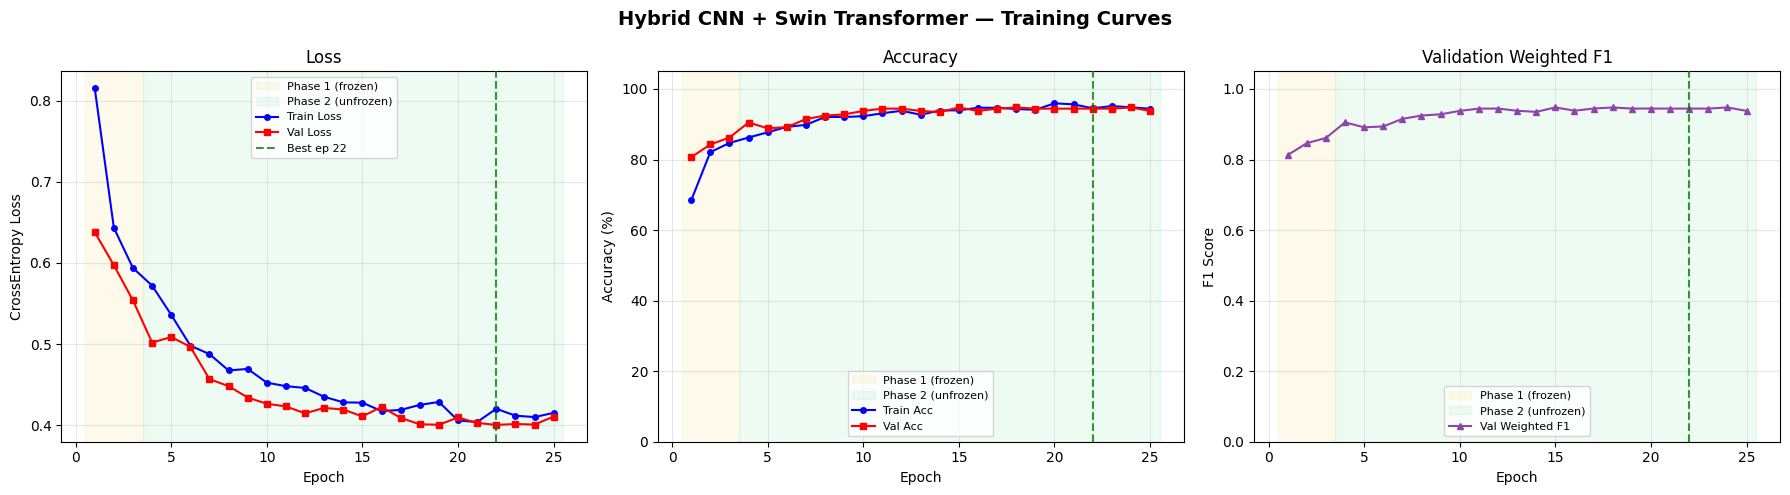


📈 Training Summary:
   Total epochs ran : 25
   Best epoch       : 22
   Best val loss    : 0.4004
   Best val acc     : 94.75%
   Best val F1      : 0.9477
   Phase 1 best val acc : 86.23%
   Phase 2 best val acc : 94.75%  (+8.52% improvement)

✅ Step 8 complete.


In [8]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))
phases     = history["phase"]

# Find phase 2 start
ph2_start = next((i + 1 for i, p in enumerate(phases) if p == 2), None)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Hybrid CNN + Swin Transformer — Training Curves",
             fontsize=14, fontweight="bold")

def add_phase_bands(ax):
    """Shade Phase 1 (yellow) and Phase 2 (green) backgrounds."""
    ax.axvspan(0.5, (ph2_start or len(epochs_ran)) - 0.5,
               alpha=0.08, color="#f1c40f", label="Phase 1 (frozen)")
    if ph2_start:
        ax.axvspan(ph2_start - 0.5, len(epochs_ran) + 0.5,
                   alpha=0.08, color="#2ecc71", label="Phase 2 (unfrozen)")

# Loss
ax = axes[0]
add_phase_bands(ax)
ax.plot(epochs_ran, history["train_loss"], "b-o", ms=4, label="Train Loss", zorder=5)
ax.plot(epochs_ran, history["val_loss"],   "r-s", ms=4, label="Val Loss",   zorder=5)
best_ep = history["val_loss"].index(min(history["val_loss"])) + 1
ax.axvline(best_ep, color="green", linestyle="--", alpha=0.8,
           label=f"Best ep {best_ep}", zorder=6)
ax.set_title("Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("CrossEntropy Loss")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Accuracy
ax2 = axes[1]
add_phase_bands(ax2)
ax2.plot(epochs_ran, [v * 100 for v in history["train_acc"]],
         "b-o", ms=4, label="Train Acc", zorder=5)
ax2.plot(epochs_ran, [v * 100 for v in history["val_acc"]],
         "r-s", ms=4, label="Val Acc",   zorder=5)
ax2.axvline(best_ep, color="green", linestyle="--", alpha=0.8, zorder=6)
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim([0, 105]); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# F1 score
ax3 = axes[2]
add_phase_bands(ax3)
ax3.plot(epochs_ran, history["val_f1"], color="#8e44ad",
         marker="^", ms=4, label="Val Weighted F1", zorder=5)
ax3.axvline(best_ep, color="green", linestyle="--", alpha=0.8, zorder=6)
ax3.set_title("Validation Weighted F1")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("F1 Score")
ax3.set_ylim([0, 1.05]); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step8_training_curves.png",
            dpi=120, bbox_inches="tight")
plt.show()

print(f"\n📈 Training Summary:")
print(f"   Total epochs ran : {len(epochs_ran)}")
print(f"   Best epoch       : {best_ep}")
print(f"   Best val loss    : {min(history['val_loss']):.4f}")
print(f"   Best val acc     : {max(history['val_acc'])*100:.2f}%")
print(f"   Best val F1      : {max(history['val_f1']):.4f}")
if ph2_start:
    p2_accs = [history["val_acc"][i] for i, p in enumerate(phases) if p == 2]
    p1_accs = [history["val_acc"][i] for i, p in enumerate(phases) if p == 1]
    if p1_accs and p2_accs:
        print(f"   Phase 1 best val acc : {max(p1_accs)*100:.2f}%")
        print(f"   Phase 2 best val acc : {max(p2_accs)*100:.2f}%  "
              f"(+{(max(p2_accs)-max(p1_accs))*100:.2f}% improvement)")
print("\n✅ Step 8 complete.")

---
## ✅ Step 9 — Final Test Evaluation & Metrics

**PDF Phase 6:** Load best checkpoint → run on test set **once only** → report all metrics.

In [9]:
# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"✅ Loaded best checkpoint:")
print(f"   Epoch    : {ckpt['epoch']}")
print(f"   Phase    : {ckpt['phase']} "
      f"({'Warmup (head only)' if ckpt['phase'] == 1 else 'Full fine-tune'})")
print(f"   Val loss : {ckpt['val_loss']:.4f}")
print(f"   Val acc  : {ckpt['val_acc']*100:.2f}%")
print(f"   Val F1   : {ckpt['val_f1']:.4f}")

# Run on test set
print("\n🔬 Running inference on test set...")
test_loss, test_acc, test_preds, test_true = evaluate(
    model, test_loader, criterion, DEVICE)

acc_pct      = test_acc * 100
weighted_f1  = f1_score(test_true, test_preds, average="weighted", zero_division=0)
macro_f1     = f1_score(test_true, test_preds, average="macro",    zero_division=0)
per_class_f1 = f1_score(test_true, test_preds, average=None,       zero_division=0)

print("\n" + "=" * 62)
print("  FINAL TEST RESULTS — Hybrid CNN + Swin Transformer")
print("=" * 62)
print(f"  {'Accuracy':<28}{acc_pct:.2f}%")
print(f"  {'Weighted F1':<28}{weighted_f1:.4f}")
print(f"  {'Macro F1':<28}{macro_f1:.4f}")
print(f"  {'Test Loss':<28}{test_loss:.4f}")
print("-" * 62)
print("  Per-Class F1:")
for cls, f1 in zip(CLASS_NAMES, per_class_f1):
    print(f"    {cls:<22} {f1:.4f}  {'█' * int(f1 * 30)}")
print("=" * 62)

print("\n📋 Detailed Classification Report:")
print(classification_report(test_true, test_preds,
                             target_names=CLASS_NAMES, digits=4))

pd.DataFrame({
    "Metric": ["Accuracy", "Weighted F1", "Macro F1"] +
               [f"F1_{c}" for c in CLASS_NAMES],
    "Value":  [acc_pct / 100, weighted_f1, macro_f1] +
               list(per_class_f1)
}).to_csv(f"/kaggle/working/{PREFIX}_step9_test_results.csv", index=False)
print("\n✅ Step 9 complete — results saved.")

✅ Loaded best checkpoint:
   Epoch    : 22
   Phase    : 2 (Full fine-tune)
   Val loss : 0.4004
   Val acc  : 94.43%
   Val F1   : 0.9444

🔬 Running inference on test set...

  FINAL TEST RESULTS — Hybrid CNN + Swin Transformer
  Accuracy                    95.77%
  Weighted F1                 0.9578
  Macro F1                    0.9493
  Test Loss                   0.3721
--------------------------------------------------------------
  Per-Class F1:
    Healthy_Leaf           0.9720  █████████████████████████████
    Leaf_Rot               0.9286  ███████████████████████████
    Leaf_Spot              0.9474  ████████████████████████████

📋 Detailed Classification Report:
              precision    recall  f1-score   support

Healthy_Leaf     0.9811    0.9630    0.9720       162
    Leaf_Rot     0.9070    0.9512    0.9286        41
   Leaf_Spot     0.9429    0.9519    0.9474       104

    accuracy                         0.9577       307
   macro avg     0.9437    0.9554    0.9493  

---
## ✅ Step 10 — Confusion Matrix & Per-Class Analysis

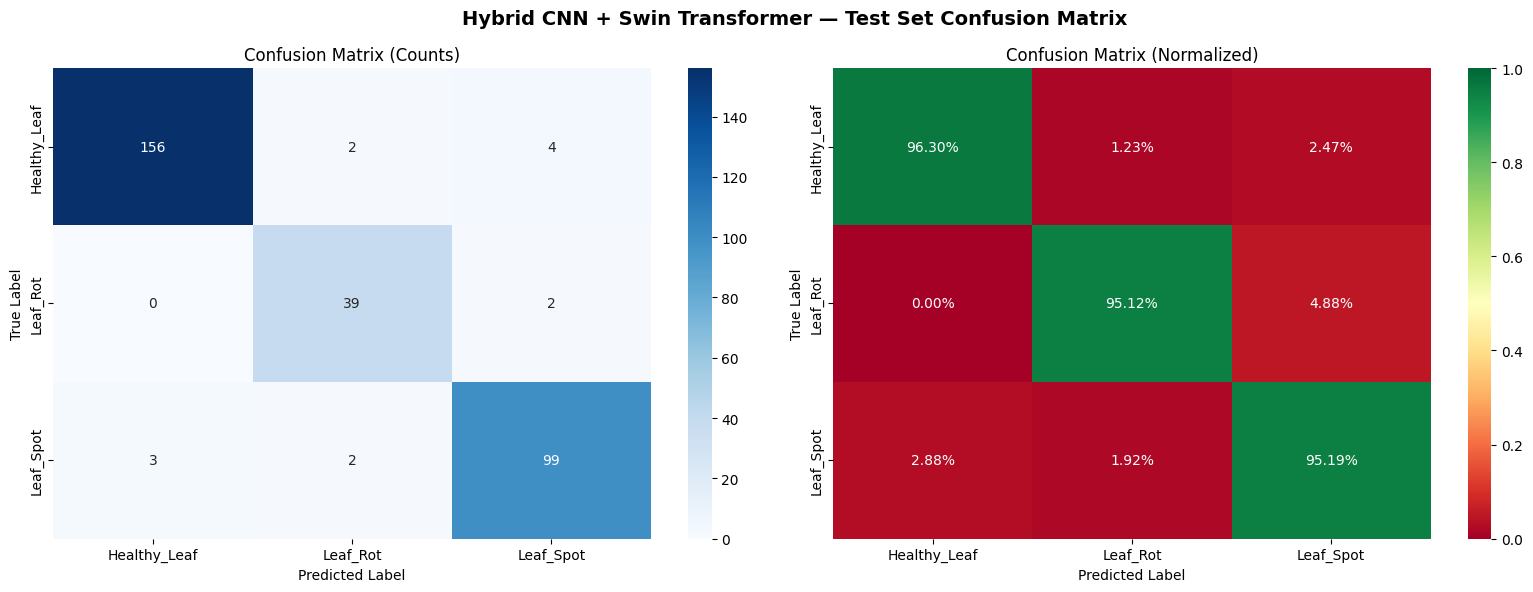

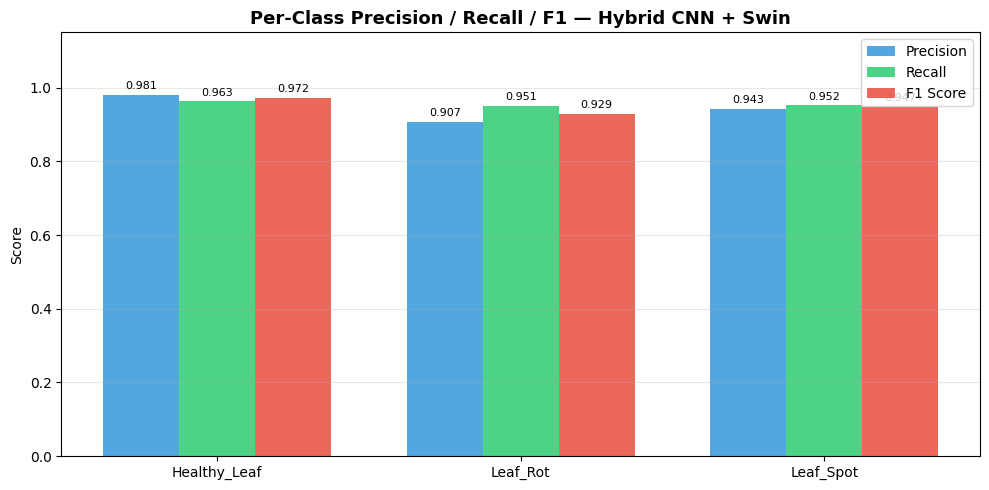

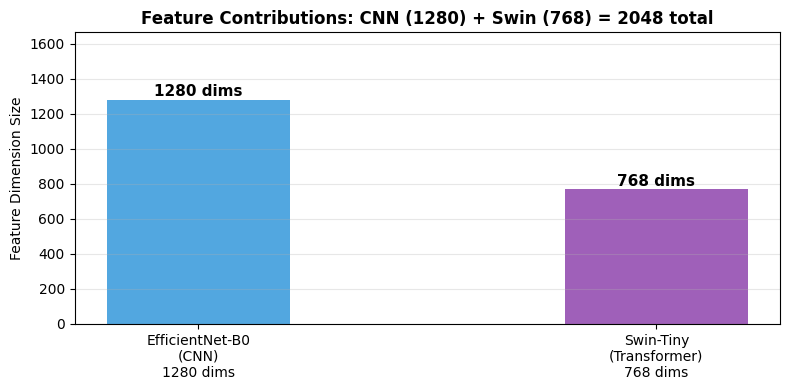


════════════════════════════════════════════════════════════════════
  🌿 HYBRID CNN + SWIN TRANSFORMER — FINAL SUMMARY
════════════════════════════════════════════════════════════════════
  Architecture  : EfficientNet-B0 (CNN) + Swin-Tiny (Transformer)
  CNN output    : 1280 dims  (local features)
  Swin output   : 768 dims  (hierarchical features)
  Fused vector  : 2048 dims  (concatenated)
  Head          : 2048→512→256→3  (GELU + BN + Dropout)
  Input shape   : [B, 3, 224, 224]
  Classes       : Healthy_Leaf, Leaf_Rot, Leaf_Spot

  Test Accuracy : 95.77%
  Weighted F1   : 0.9578
  Macro F1      : 0.9493
────────────────────────────────────────────────────────────────────
    Healthy_Leaf        F1=0.9720  Prec=0.9811  Rec=0.9630
    Leaf_Rot            F1=0.9286  Prec=0.9070  Rec=0.9512
    Leaf_Spot           F1=0.9474  Prec=0.9429  Rec=0.9519
────────────────────────────────────────────────────────────────────
  Saved files:
    ✓ /kaggle/working/hybrid_cnn_swin_step3_distributi

In [10]:
# ── Confusion Matrix ──────────────────────────────────────────────────────
cm      = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Hybrid CNN + Swin Transformer — Test Set Confusion Matrix",
             fontsize=14, fontweight="bold")
sns.heatmap(cm,      annot=True, fmt="d",   cmap="Blues",  ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="RdYlGn", ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_confusion_matrix.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── Per-class Precision / Recall / F1 bar chart ───────────────────────────
per_prec   = precision_score(test_true, test_preds, average=None, zero_division=0)
per_recall = recall_score(test_true,    test_preds, average=None, zero_division=0)

fig2, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASS_NAMES)); w = 0.25
b1 = ax.bar(x - w, per_prec,     w, label="Precision",
            color="#3498db", alpha=0.85)
b2 = ax.bar(x,     per_recall,   w, label="Recall",
            color="#2ecc71", alpha=0.85)
b3 = ax.bar(x + w, per_class_f1, w, label="F1 Score",
            color="#e74c3c", alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_title("Per-Class Precision / Recall / F1 — Hybrid CNN + Swin",
             fontsize=13, fontweight="bold")
ax.set_ylim([0, 1.15])
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_per_class_metrics.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── Branch contribution chart ─────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 4))
branch_data = {
    f"EfficientNet-B0\n(CNN)\n{EFF_FEAT_DIM} dims": EFF_FEAT_DIM,
    f"Swin-Tiny\n(Transformer)\n{SWIN_FEAT_DIM} dims": SWIN_FEAT_DIM,
}
bars = ax3.bar(branch_data.keys(), branch_data.values(),
               color=["#3498db", "#8e44ad"], alpha=0.85, width=0.4)
for bar, val in zip(bars, branch_data.values()):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 20,
             f"{val} dims", ha="center",
             fontsize=11, fontweight="bold")
ax3.set_title(
    f"Feature Contributions: CNN ({EFF_FEAT_DIM}) + Swin ({SWIN_FEAT_DIM}) = {FUSED_DIM} total",
    fontsize=12, fontweight="bold")
ax3.set_ylabel("Feature Dimension Size")
ax3.set_ylim([0, max(EFF_FEAT_DIM, SWIN_FEAT_DIM) * 1.3])
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"/kaggle/working/{PREFIX}_step10_feature_contributions.png",
            dpi=120, bbox_inches="tight")
plt.show()

# ── Final Summary ─────────────────────────────────────────────────────────
print("\n" + "═" * 68)
print("  🌿 HYBRID CNN + SWIN TRANSFORMER — FINAL SUMMARY")
print("═" * 68)
print(f"  Architecture  : EfficientNet-B0 (CNN) + Swin-Tiny (Transformer)")
print(f"  CNN output    : {EFF_FEAT_DIM} dims  (local features)")
print(f"  Swin output   : {SWIN_FEAT_DIM} dims  (hierarchical features)")
print(f"  Fused vector  : {FUSED_DIM} dims  (concatenated)")
print(f"  Head          : {FUSED_DIM}→{HEAD_DIM1}→{HEAD_DIM2}→{NUM_CLASSES}  (GELU + BN + Dropout)")
print(f"  Input shape   : [B, 3, {IMG_SIZE}, {IMG_SIZE}]")
print(f"  Classes       : {', '.join(CLASS_NAMES)}")
print(f"")
print(f"  Test Accuracy : {acc_pct:.2f}%")
print(f"  Weighted F1   : {weighted_f1:.4f}")
print(f"  Macro F1      : {macro_f1:.4f}")
print("─" * 68)
for cls, f1, p, r in zip(CLASS_NAMES, per_class_f1, per_prec, per_recall):
    print(f"    {cls:<18}  F1={f1:.4f}  Prec={p:.4f}  Rec={r:.4f}")
print("─" * 68)
print("  Saved files:")
for f in [
    f"{PREFIX}_step3_distribution.png",
    f"{PREFIX}_step3_samples.png",
    f"{PREFIX}_step4_augmentation.png",
    f"{PREFIX}_step8_training_curves.png",
    f"{PREFIX}_step9_test_results.csv",
    f"{PREFIX}_step10_confusion_matrix.png",
    f"{PREFIX}_step10_per_class_metrics.png",
    f"{PREFIX}_step10_feature_contributions.png",
    f"best_{PREFIX}_model.pth",
]:
    print(f"    ✓ /kaggle/working/{f}")
print("═" * 68)
print("  ✅ Step 10 complete — Hybrid CNN + Swin pipeline finished!")
print("═" * 68)